# Telco customer churn: IBM dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('Telco_customer_churn.xlsx')
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


## Data Cleaning

In [3]:
df.drop(columns = ['CustomerID', 'Count', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Value', 'Churn Score', 'CLTV'], inplace = True)

Removed identifiers, high cardinality location fields, and leakage prone variables like churn score and CLTV

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            7043 non-null   object 
 1   State              7043 non-null   object 
 2   City               7043 non-null   object 
 3   Gender             7043 non-null   object 
 4   Senior Citizen     7043 non-null   object 
 5   Partner            7043 non-null   object 
 6   Dependents         7043 non-null   object 
 7   Tenure Months      7043 non-null   int64  
 8   Phone Service      7043 non-null   object 
 9   Multiple Lines     7043 non-null   object 
 10  Internet Service   7043 non-null   object 
 11  Online Security    7043 non-null   object 
 12  Online Backup      7043 non-null   object 
 13  Device Protection  7043 non-null   object 
 14  Tech Support       7043 non-null   object 
 15  Streaming TV       7043 non-null   object 
 16  Streaming Movies   7043 

We review the schema using df.info() in order to validate data types and missing values.
Total Charges is stored as a 'object' instead of numeric type

In [5]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors = 'coerce')
df['Total Charges'].isna().sum()

11

In [6]:
df[(df['Tenure Months'] == 0) & (df['Total Charges'].isna())]

,Country,State,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Reason
2234,United States,California,San Bernardino,Female,No,Yes,No,0,No,No phone service,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,NaN
2438,United States,California,Independence,Male,No,No,No,0,Yes,No,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,NaN
2568,United States,California,San Mateo,Female,No,Yes,No,0,Yes,No,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,NaN
2667,United States,California,Cupertino,Male,No,Yes,Yes,0,Yes,Yes,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,NaN
2856,United States,California,Redcrest,Female,No,Yes,No,0,No,No phone service,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,NaN
4331,United States,California,Los Angeles,Male,No,Yes,Yes,0,Yes,No,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,NaN
4687,United States,California,Sun City,Male,No,Yes,Yes,0,Yes,Yes,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,NaN
5104,United States,California,Ben Lomond,Female,No,Yes,Yes,0,Yes,No,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,NaN
5719,United States,California,La Verne,Male,No,Yes,Yes,0,Yes,No,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,NaN
6772,United States,California,Bell,Female,No,Yes,Yes,0,Yes,Yes,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,NaN


Clearly the Total Charges is na only for new customers. Therefor it is safe to replace the na values with 0 instead

In [7]:
df['Total Charges'] = df['Total Charges'].fillna(0)

In [8]:
df.isna().sum()

Country                 0
State                   0
City                    0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Reason         5174
dtype: int64

To understand the association between the numerical features and the target ("Churn Label") we can calculate the correlation between them

## EDA

In [9]:
df['Churn Label'] = df['Churn Label'].apply(lambda x : 1 if x == 'Yes' else 0)

In [10]:
cols = [
    'Tenure Months',
    'Monthly Charges',
    'Total Charges',
    'Churn Label'
]

corr = df[cols].copy()
corr

,Tenure Months,Monthly Charges,Total Charges,Churn Label
0,2,53.85,108.15,1
1,2,70.70,151.65,1
2,8,99.65,820.50,1
3,28,104.80,3046.05,1
4,49,103.70,5036.30,1
...,...,...,...,...
7038,72,21.15,1419.40,0
7039,24,84.80,1990.50,0
7040,72,103.20,7362.90,0
7041,11,29.60,346.45,0


In [11]:
corr.corr()['Churn Label'].sort_values(ascending = False)

Churn Label        1.000000
Monthly Charges    0.193356
Total Charges     -0.198324
Tenure Months     -0.352229
Name: Churn Label, dtype: float64

_Total Charges = Monthly Charges * Tenure Months_ \
So this is partially driven by tenure and it is not an independent churn driver 

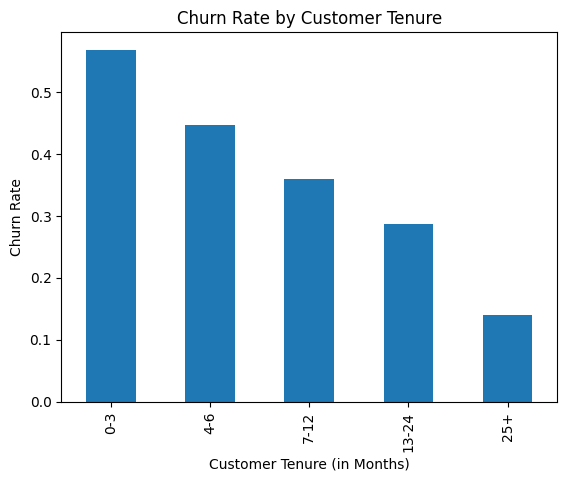

In [12]:
df['tenure_buckets'] = pd.cut(df['Tenure Months'], bins = [0, 3, 6, 12, 24, 72], labels = ['0-3', '4-6', '7-12', '13-24', '25+'])
churn_by_tenure = df.groupby('tenure_buckets', observed = True)['Churn Label'].mean()
churn_by_tenure.plot(kind = 'bar')
plt.ylabel('Churn Rate')
plt.xlabel('Customer Tenure (in Months)')
plt.title('Churn Rate by Customer Tenure')
plt.show()

Tenure Months : -0.35
- Customer with longer tenure are much less likely to churn (strong negative correlation)
- Churn risk is highest among **new customers**

Buisness Implications :
- Early customer experience is critical for long term retention
- The ***first 1-3 months*** represents a high-rist window where targeted onboarding and engagement cant reduce churning

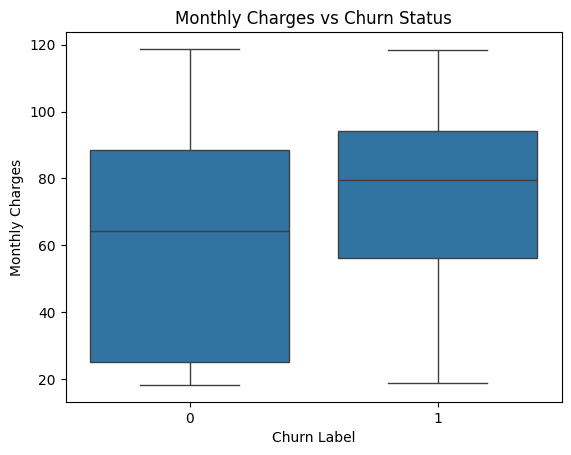

In [13]:
sns.boxplot(x = 'Churn Label', y = 'Monthly Charges', data = df)
plt.title('Monthly Charges vs Churn Status')
plt.show()

Monthly Charges : +0.19
- Higher monthly bills are associated with higher churn 

Buisness Implications :
- **Price dissatisfaction** is a churn trigger
- Discount or bundles may prove helpful in reducing chrun

We can consider some important categorical variables such as Contract, Add on Services and Payment Types that can directly point at important buisness insights

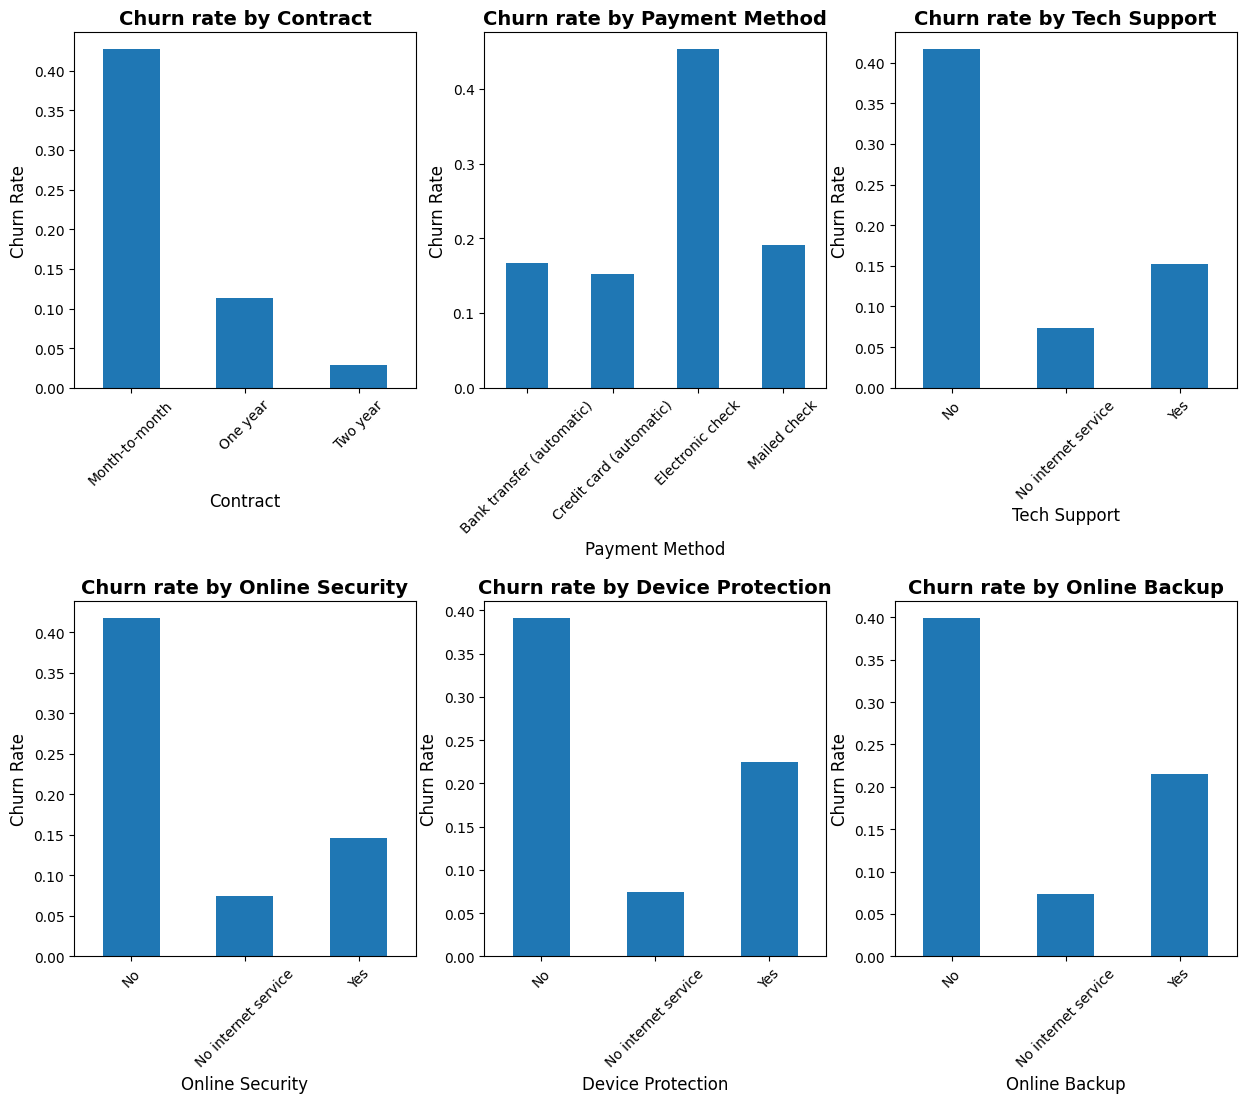

In [14]:
cols = ['Contract', 'Payment Method', 'Tech Support', 'Online Security', 'Device Protection', 'Online Backup']
fig, axe = plt.subplots(2, 3, figsize = (15, 12))
axe = axe.flatten()
for i, col in enumerate(cols) :
    df.groupby(col)['Churn Label'].mean().plot(kind = 'bar', ax = axe[i])
    axe[i].set_xlabel(col, fontsize = 12)
    axe[i].set_ylabel('Churn Rate', fontsize = 12)
    axe[i].set_title(f'Churn rate by {col}', fontsize = 14, fontweight = 'bold')
    axe[i].tick_params(axis = 'x', labelrotation = 45, labelsize = 10)
plt.subplots_adjust(hspace=0.6) 

**Contract Type** :\
Customer on month-to-month contracts churn 4x more tha customers on one year and 14x on two year contracts

**Payment Type** :\
Customer using electronics check churn nearly 3x more than auto pay users

**Add On Services** :\
Customers who do not subscribe for add on services like Tech Support, Online Security Online Backup and Device Protection exhibit higher churn rate compared to customers who subscribed to these services.

Buisness Insight and Implications :
- Contract commitment drastically reduces churn
- Incevtivizing upgrades to 1-year and 2-year plans after 2-3 months to promote conversion
- Push auto pay enrollment during onboarding
- Value added service reduces churn and increases customer retention
- Bundling support and security service during the early customer lifecycle, could significantly reduce the churn

In [15]:
cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Streaming TV', 'Streaming Movies']
for col in cols : 
    print(df.groupby(col)['Churn Label'].mean())
    print('~' * 40)

Gender
Female    0.269209
Male      0.261603
Name: Churn Label, dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Senior Citizen
No     0.236062
Yes    0.416813
Name: Churn Label, dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Partner
No     0.329580
Yes    0.196649
Name: Churn Label, dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Dependents
No     0.325517
Yes    0.065151
Name: Churn Label, dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Phone Service
No     0.249267
Yes    0.267096
Name: Churn Label, dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Multiple Lines
No                  0.250442
No phone service    0.249267
Yes                 0.286099
Name: Churn Label, dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Streaming TV
No                     0.335231
No internet service    0.074050
Yes                    0.300702
Name: Churn Label, dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Streaming Movies
No                     0.3

***These features either have no significant difference or we cant drive a useful buisness decision from them***

### Root Cause Analysis: Drivers of Customer Churn

Customer churn is largely influenced by how flexible, frictionless, and valuable the service feels to customers not by random behavior. Customers on month-to-month contracts, those facing payment friction, and those without support or protection services are far more likely to leave.

The risk is especially high early in the customer lifecycle. New customers who do not receive adequate support or bundled value-added services are the most vulnerable to churn.

Focusing on better contract structures, smoother payment experiences, and stronger early-stage service bundles presents the greatest opportunity to meaningfully reduce churn.